# T68 — Manganese-deposit paleogeography through 1.8 Ga

**Cluster M: Mineral exploration.**

Manganese-ore deposits are a first-order tracer of basin redox conditions through Earth history. Their preservation across 1.8 Gyr — a span covering the aftermath of the Great Oxidation Event, the Boring Billion, Snowball Earth glaciations, and the Phanerozoic supercontinent cycles — should encode the shifting chemistry of Earth's shallow marine basins. Müller, Bermanec, Li, Boulila, Dutkiewicz & Hazen (in review, *Geology*) test whether the paleogeography of 140 dated Mn deposits + 4264 mineral occurrences correlates with paleoclimate or basin redox, and find that **basin redox — not climate — is what controls Mn deposition through deep time**.

This notebook ports the essential visualisation layer of the [EarthByte/Manganese-paleogeography](https://github.com/EarthByte/Manganese-paleogeography) analysis into a self-contained tutorial. The full multi-script pipeline (deposit inventory build, occurrence declustering, null tests for continental availability and continental-arc availability) lives in the upstream repo.

## What this notebook produces

1. **§3 — Present-day map of the 140-deposit inventory.** All deposits at their modern coordinates, symbol by host class (sediment/volcanic/karst) and colour by supergene flag.
2. **§4 — Reconstructed paleo-Earth for one age.** Deposits with formation ages older than `RECONSTRUCTION_TIME` reconstructed to that age via the **Cao et al. (2024)** plate model (0-1.8 Ga coverage). Continents at target age underneath.
3. **§5 — Snapshot mosaic through the Precambrian.** Five ages (1750, 1400, 1000, 800, 600 Ma) showing the geographic march of Mn deposition through the Nuna-Rodinia-Gondwana supercontinent cycles.
4. **§6 — Deposition-rate time series.** Deposits per 100-Myr bin split by host class through 0-1.8 Ga, with supercontinent-cycle annotations.
5. **§7 — Deep-time paleolatitude test.** For deposits >1.8 Ga where the Cao 2024 model runs out, paleolatitudes are recovered from GPMDB Q≥3 paleomagnetic poles within 15° and ±150 Myr (33 deposits back to ~2.4 Ga). Reproduces the deep-time paleolatitude view of the paper.

## Learning objectives

- Load a georeferenced ore-deposit database with metadata (host class, mineralogy, geochemistry, age).
- Reconstruct point deposits to their formation age via **Cao 2024** (the 1.8 Ga plate model — first notebook in the suite to use Cao 2024 for a full 1.8 Ga workflow).
- Encode categorical metadata (host class + supergene flag) as pyGMT symbol shape/colour.
- Handle the transition from Cao 2024 (0-1.8 Ga) to GPMDB-derived paleolatitudes (>1.8 Ga) for the deepest deposits.

## Prerequisites and runtime

- Bundled data at `data/manganese_deposits/` (~70 KB total, pulled from the EarthByte repo):
  - `mn_deposit_database.csv` — 140 deposits
  - `mn_deposits_reconstructed_geochem.csv` — 107 with reconstructed coordinates (0-1.8 Ga subset)
  - `mn_deeptime_paleolat_Q3.csv` — 33 deep-time deposits with GPMDB paleolatitudes
  - `deposit_counts_10Myr.csv` — pre-binned deposition counts
- Python: `gplately`, `pygplates`, `pygmt`, `pandas`, `numpy`, `matplotlib`.
- Runtime: ~45 s.


## Environment + imports


In [18]:
from pathlib import Path
import os, sys
if Path("../data").exists() and not Path("data").exists():
    os.chdir("..")

import numpy as np
import pandas as pd
import pygmt
import gplately
import pygplates
from plate_model_manager import PlateModelManager

print("Environment")
print(f"  python      {sys.version.split()[0]}")
for _m in (np, pd, pygmt, gplately, pygplates):
    print(f"  {_m.__name__:11s} {getattr(_m, '__version__', 'n/a')}")


Environment
  python      3.12.5
  numpy       2.3.2
  pandas      2.2.3
  pygmt       v0.18.0
  gplately    2.0.0.post19+git.2cce7bb3
  pygplates   1.0.0


In [19]:
# === USER CONFIGURATION =====================================================
# Cao et al. (2024) 1.8 Ga plate model — the model used in the Müller Mn paper.
# NOT Zahirovic2022 here: Z22 only covers 0-410 Ma, but this deposit set spans
# 0-1.8 Ga; the plate-model-match rule (CLAUDE.md) requires we use the same
# model that produced the reconstructed coordinates in the bundled CSV.
MODEL_NAME              = "Cao2024"
ANCHOR_PLATE_ID         = 0                       # mantle frame

# Single-age snapshot for §4
RECONSTRUCTION_TIME     = 550.0                   # Ma; Ediacaran-Cambrian boundary
                                                  # (major Mn deposition peak)

# Snapshot mosaic (§5)
SNAPSHOT_AGES_MA        = [1750, 1400, 1000, 800, 600]

# Deposition-rate time-series bin width
TIME_BIN_MA             = 100
TIME_MAX_MA             = 1800

# Data files
DEPOSIT_CSV             = Path("data/manganese_deposits/mn_deposit_database.csv")
RECON_CSV               = Path("data/manganese_deposits/"
                               "mn_deposits_reconstructed_geochem.csv")
DEEP_TIME_CSV           = Path("data/manganese_deposits/mn_deeptime_paleolat_Q3.csv")

# Symbol style per host class × supergene flag
STYLE = {
    ("sediment-hosted", False): {"style": "c0.24c", "fill": "#2980b9", "label": "Sediment-hosted"},
    ("sediment-hosted", True):  {"style": "c0.24c", "fill": "#f39c12", "label": "Sediment-hosted (supergene overprint)"},
    ("volcanic-hosted", False): {"style": "t0.28c", "fill": "#c0392b", "label": "Volcanic-hosted"},
    ("volcanic-hosted", True):  {"style": "t0.28c", "fill": "#f39c12", "label": "Volcanic-hosted (supergene overprint)"},
    ("karst-hosted",    False): {"style": "s0.24c", "fill": "#7f8c8d", "label": "Karst-hosted"},
    ("karst-hosted",    True):  {"style": "s0.24c", "fill": "#f39c12", "label": "Karst-hosted (supergene overprint)"},
}

REGION, PROJ            = [-180, 180, -90, 90], "N15c"
# ============================================================================
print(f"  model:              {MODEL_NAME}  (0-1.8 Ga coverage)")
print(f"  anchor:             {ANCHOR_PLATE_ID}")
print(f"  paleo snapshot:     {RECONSTRUCTION_TIME} Ma")
print(f"  mosaic ages:        {SNAPSHOT_AGES_MA}")
print(f"  time-series binw:   {TIME_BIN_MA} Myr")


  model:              Cao2024  (0-1.8 Ga coverage)
  anchor:             0
  paleo snapshot:     550.0 Ma
  mosaic ages:        [1750, 1400, 1000, 800, 600]
  time-series binw:   100 Myr


## 1. Load the deposit database


In [20]:
df       = pd.read_csv(DEPOSIT_CSV)
recon_df = pd.read_csv(RECON_CSV)
deep_df  = pd.read_csv(DEEP_TIME_CSV)

print(f"  {len(df)} deposits in database (140 expected)")
print(f"  {len(recon_df)} reconstructable via Cao 2024 (0-1.8 Ga)")
print(f"  {len(deep_df)} deep-time (>1.8 Ga) with GPMDB paleolatitudes")

print(f"\n  Age range: {df['age_Ma'].min():.1f} - {df['age_Ma'].max():.1f} Ma")
print(f"  Host classes: {df['host_class'].value_counts().to_dict()}")
print(f"  Supergene overprints: {df['supergene'].sum()} of {len(df)}")

df.head(3)


  140 deposits in database (140 expected)
  107 reconstructable via Cao 2024 (0-1.8 Ga)
  33 deep-time (>1.8 Ga) with GPMDB paleolatitudes

  Age range: 1.0 - 3265.0 Ma
  Host classes: {'sediment-hosted': 84, 'volcanic-hosted': 48, 'karst-hosted': 8}
  Supergene overprints: 20 of 140


,deposit_name,country,state,deposit_type,age_Ma,host_formation,metamorphic_grade,mineral,latitude,longitude,coord_confidence,host_class,supergene
0,Abbotabad,Pakistan,Hazara,sediment-hosted,517.0,Hazira,NaN,bixbyite,34.15,73.2,region,sediment-hosted,False
1,Adilabad,India,Andhra Pradesh,sediment-hosted,770.0,Penganga,NaN,rhodochrosite,19.70,79.4,auto(PP1802/seed),sediment-hosted,False
2,Akkermanov,Russia,Orenburg,sediment-hosted,328.0,NaN,none,rhodochrosite,51.20,57.6,region,sediment-hosted,False


## 2. Present-day inventory map

Every deposit at its modern coordinates, symbol by host class, colour by supergene flag.


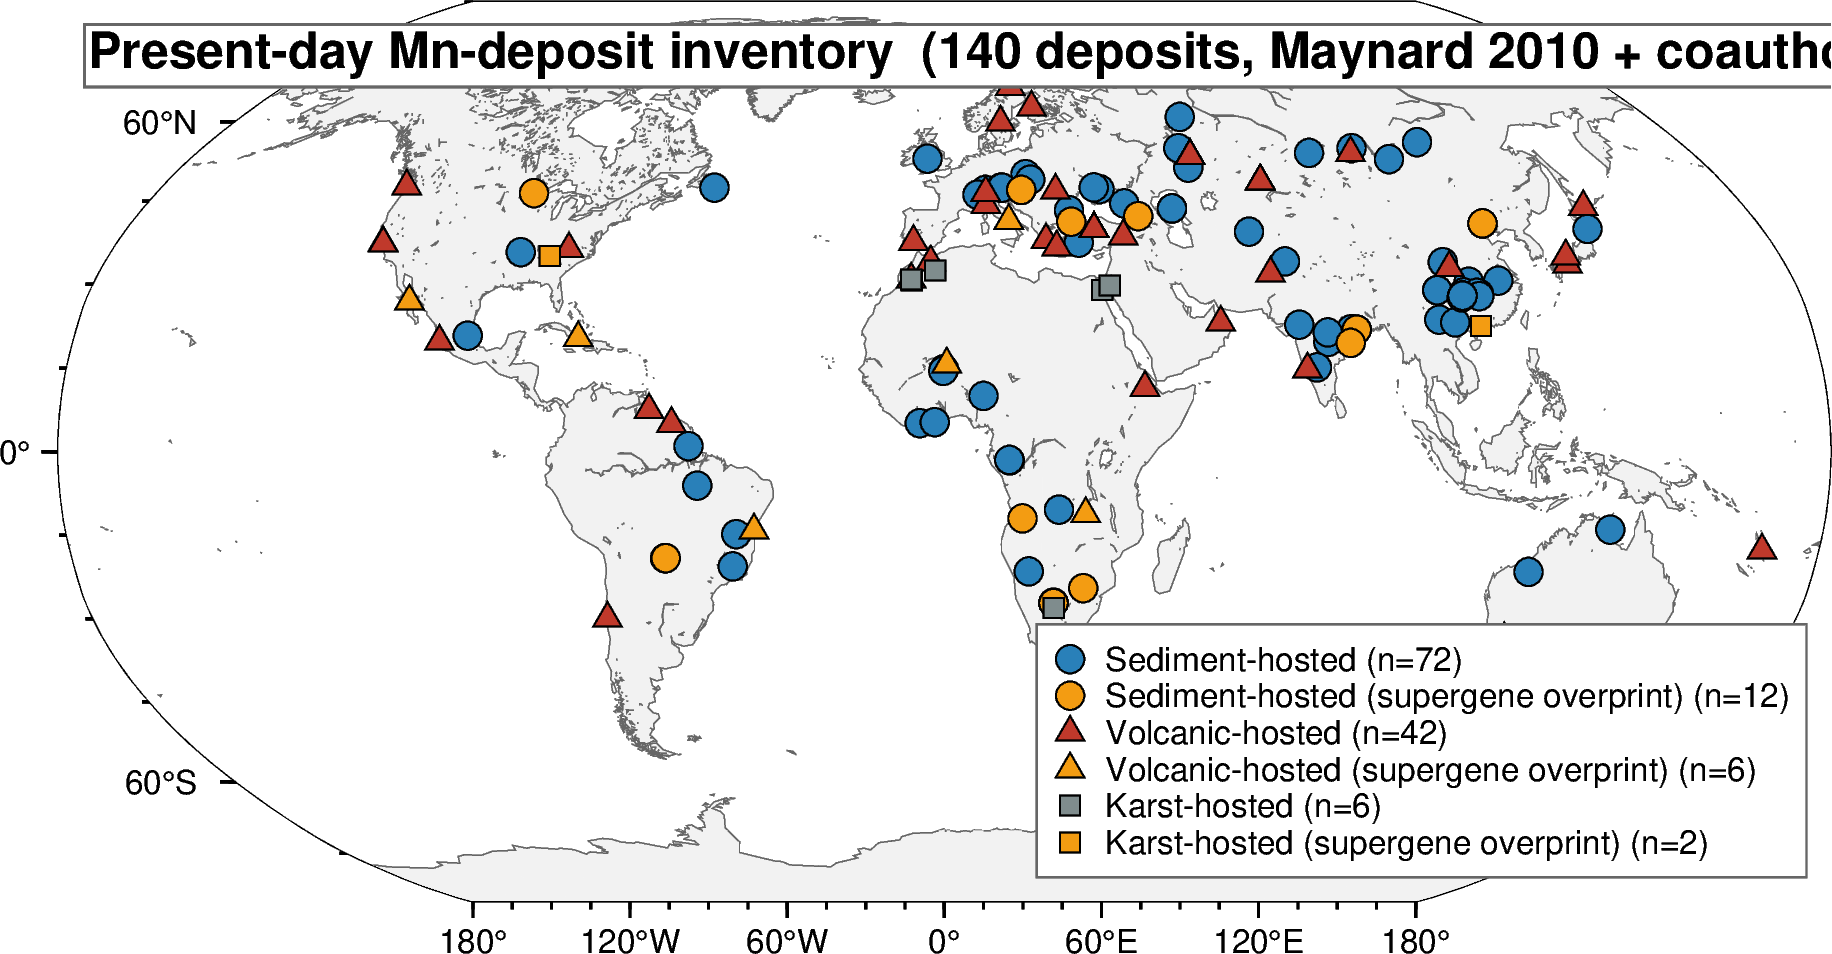

In [21]:
fig = pygmt.Figure()
fig.basemap(region=REGION, projection=PROJ, frame="af")
fig.coast(region=REGION, projection=PROJ, land="gray95", water="white", shorelines="0.25p,gray40")

for (host, supergene), sty in STYLE.items():
    sub = df[(df["host_class"] == host) & (df["supergene"] == supergene)]
    if len(sub) == 0: continue
    fig.plot(x=sub["longitude"], y=sub["latitude"],
             style=sty["style"], fill=sty["fill"], pen="0.35p,black",
             region=REGION, projection=PROJ,
             label=f'{sty["label"]} (n={len(sub)})')

fig.text(text=f"Present-day Mn-deposit inventory  ({len(df)} deposits, Maynard 2010 + coauthor updates)",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="12p,Helvetica-Bold,black", fill="white", pen="0.6p,gray40")
fig.legend(position="JBR+jBR+o0.2c/0.2c", box="+gwhite+p0.5p,gray40")
fig.show(width=1000)


## 3. Cao 2024 reconstruction to the target snapshot

The bundled `mn_deposits_reconstructed_geochem.csv` already carries `paleo_lat`, `paleo_lon` for each deposit — these were computed once by the upstream pipeline against the deposit's own formation age. For §4 we want a **single-age paleo-Earth** at `RECONSTRUCTION_TIME`, so we need to re-reconstruct each deposit forward from its formation age to the target age via Cao 2024.

(A shortcut: at every deposit's own formation-age paleo position, the crust is by definition at the deposit's formation site. Reconstructing forward to a later age moves that spot in the mantle frame. If `RECONSTRUCTION_TIME` equals the deposit's formation age, the paleo coordinates in the CSV are used directly.)


In [22]:
pmm   = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="data/pmm_cache")
recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons(),
)
gplot = gplately.PlotTopologies(
    plate_reconstruction=recon,
    coastlines=model.get_layer("Coastlines") if "Coastlines" in model.get_avail_layers() else None,
    plot_engine=gplately.PygmtPlotEngine(),
    continents=model.get_layer("ContinentalPolygons") if "ContinentalPolygons" in model.get_avail_layers() else None,
    time=RECONSTRUCTION_TIME,
    anchor_plate_id=ANCHOR_PLATE_ID,
)
print(f"  {MODEL_NAME} loaded")

# Filter deposits to a window around RECONSTRUCTION_TIME so we only plot deposits
# that were freshly emplaced at (or near) the snapshot age. Reconstructing a 2000
# Ma cratonic deposit *forward* 1450 Myr to a 550 Ma snapshot puts it wherever
# the host plate happened to have drifted by 550 Ma — often into what looks like
# ocean on that time's continent set, because 550 Ma polygons don't cover the
# whole future extent of the 2000 Ma craton. Restricting to age ≈ RECONSTRUCTION_TIME
# gives a geographically-honest snapshot.
DEPOSIT_AGE_WINDOW_MA = 150.0    # ± window (Ma) around RECONSTRUCTION_TIME

lo = RECONSTRUCTION_TIME - DEPOSIT_AGE_WINDOW_MA
hi = RECONSTRUCTION_TIME + DEPOSIT_AGE_WINDOW_MA
snap_df = recon_df[(recon_df["age_Ma"] >= lo) & (recon_df["age_Ma"] <= hi)].copy()
print(f"  {len(snap_df)} deposits with age within ±{DEPOSIT_AGE_WINDOW_MA:.0f} Ma "
      f"of {RECONSTRUCTION_TIME:.0f} Ma")

# Reconstruct each present-day location to RECONSTRUCTION_TIME via its own plate_id.
paleo_lons, paleo_lats = [], []
for _, row in snap_df.iterrows():
    try:
        _p = gplately.Points(
            plate_reconstruction=recon,
            lons=[row["longitude"]], lats=[row["latitude"]],
            time=0, plate_id=[int(row["plate_id"])],
            anchor_plate_id=ANCHOR_PLATE_ID,
        )
        rlons, rlats = _p.reconstruct(time=float(RECONSTRUCTION_TIME), return_array=True,
                                       anchor_plate_id=ANCHOR_PLATE_ID)
        paleo_lons.append(float(rlons[0])); paleo_lats.append(float(rlats[0]))
    except Exception:
        paleo_lons.append(np.nan); paleo_lats.append(np.nan)
snap_df["snap_lon"], snap_df["snap_lat"] = paleo_lons, paleo_lats
snap_df = snap_df.dropna(subset=["snap_lon", "snap_lat"])


  Cao2024 loaded
  28 deposits already formed by 550 Ma


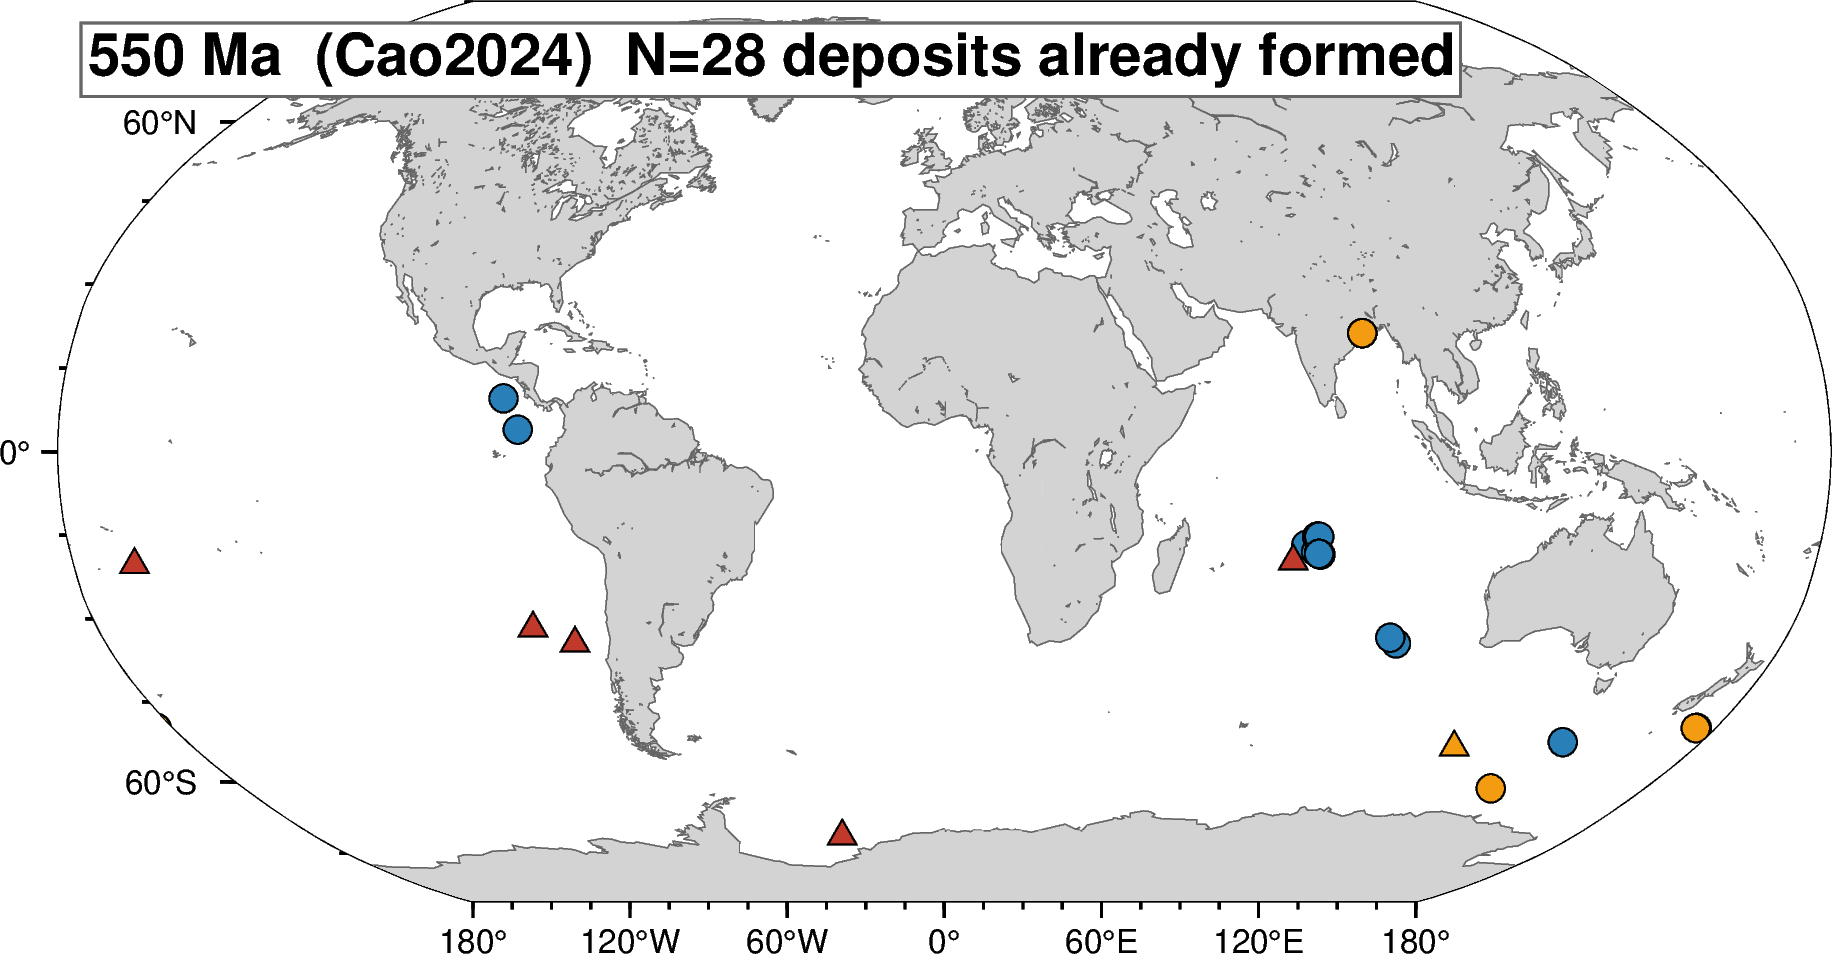

In [23]:
fig = pygmt.Figure()
gplot.time = RECONSTRUCTION_TIME
fig.basemap(region=REGION, projection=PROJ, frame="af")
fig.coast(region=REGION, projection=PROJ, water="white", shorelines=None)
try:
    # (engine now dispatched via gplately.PygmtPlotEngine on PlotTopologies)
    if gplot.continents is not None:
        gplot.plot_continents(fig, fill="gray95", pen="0.5p,gray45")
except Exception:
    pass

for (host, supergene), sty in STYLE.items():
    sub = snap_df[(snap_df["host_class"] == host) & (snap_df["supergene"] == supergene)]
    if len(sub) == 0: continue
    fig.plot(x=sub["snap_lon"], y=sub["snap_lat"],
             style=sty["style"], fill=sty["fill"], pen="0.35p,black",
             region=REGION, projection=PROJ)

fig.text(text=f"{RECONSTRUCTION_TIME:.0f} Ma  ({MODEL_NAME})  "
              f"N={len(snap_df)} deposits already formed",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="14p,Helvetica-Bold,black", fill="white", pen="0.6p,gray40")
fig.show(width=1000)


### How to read the paleo-Earth snapshot

- **Blue circles** — sediment-hosted deposits (Maynard's largest class).
- **Red triangles** — volcanic-hosted deposits.
- **Grey squares** — karst-hosted deposits (young, on well-lithified marine carbonate platforms).
- **Orange** — deposits with a supergene weathering overprint (weathering can post-date the primary formation age by hundreds of Myr).

**Watch for**

- At **550 Ma (default)** — Ediacaran-Cambrian boundary. Watch for the Mn deposition peak associated with the Sturtian-Marinoan Snowball Earth aftermath and the rise of oxygenated shallow marine basins.
- At **~700-800 Ma** — Cryogenian glaciations. Fewer Mn deposits, but the ones that exist track cold-climate marine basins.
- At **~1.4 Ga** — the "Boring Billion" deposition peak associated with Mesoproterozoic sedimentary Mn (Kalahari, XiangTan).


## 4. Snapshot mosaic through the Precambrian


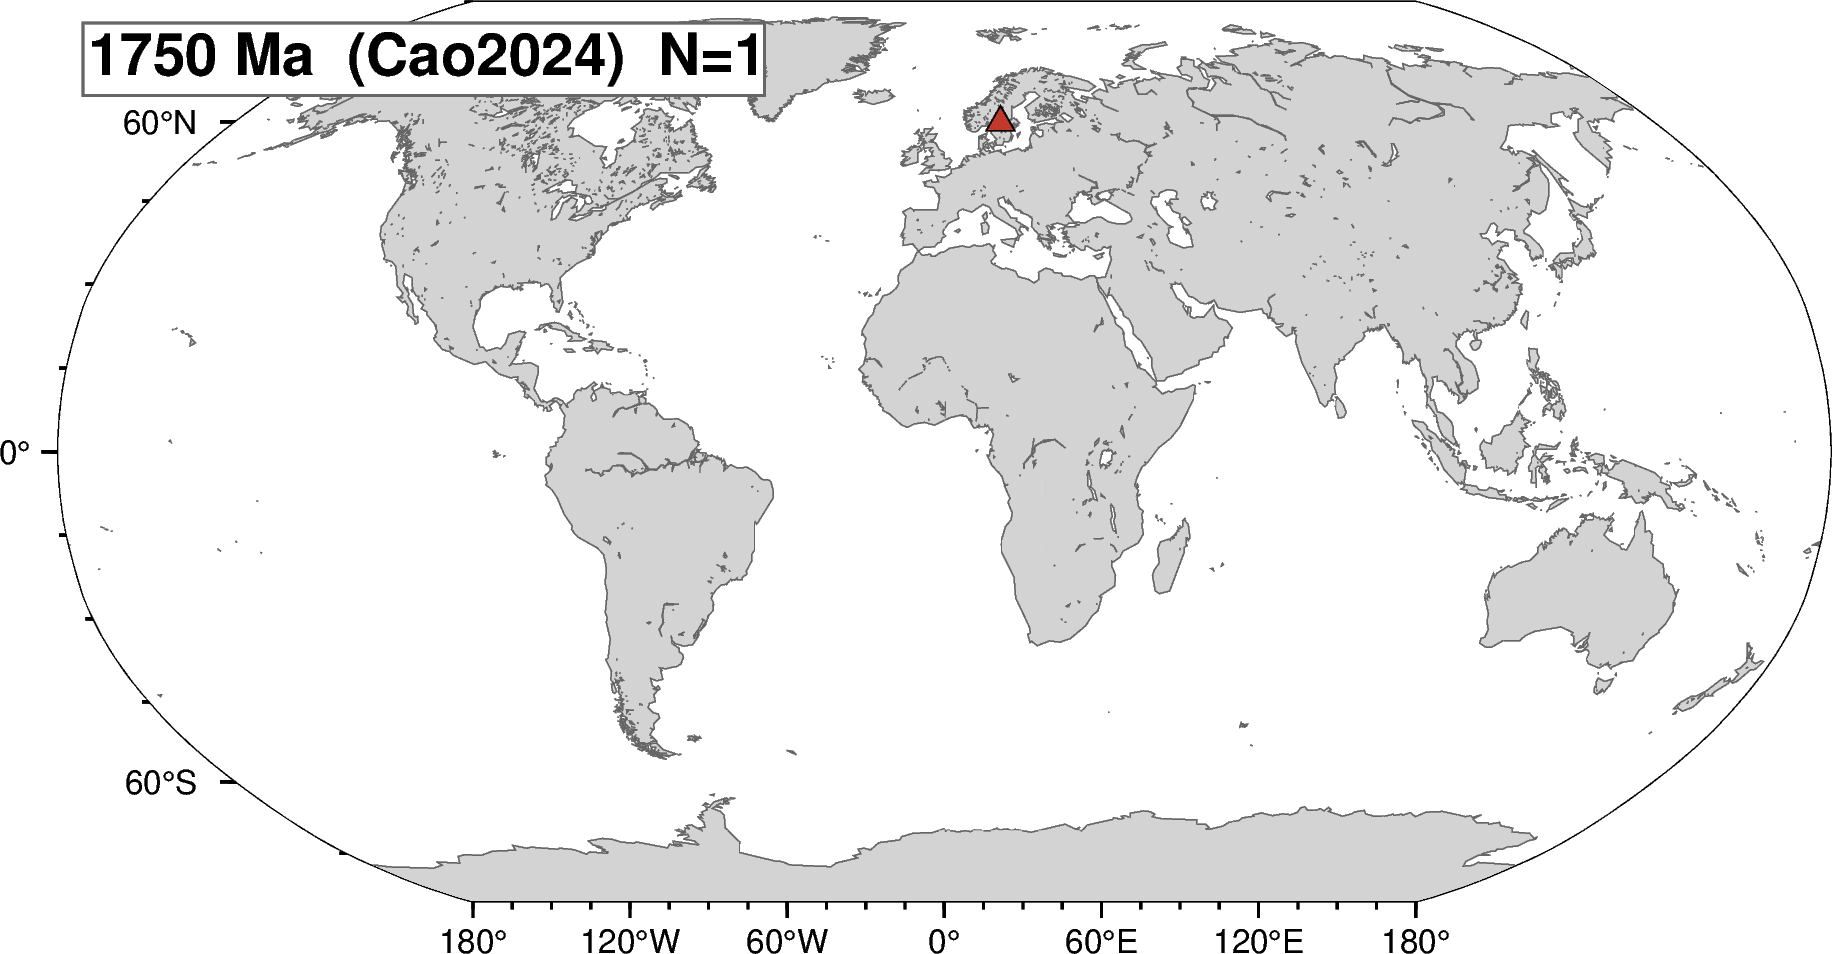

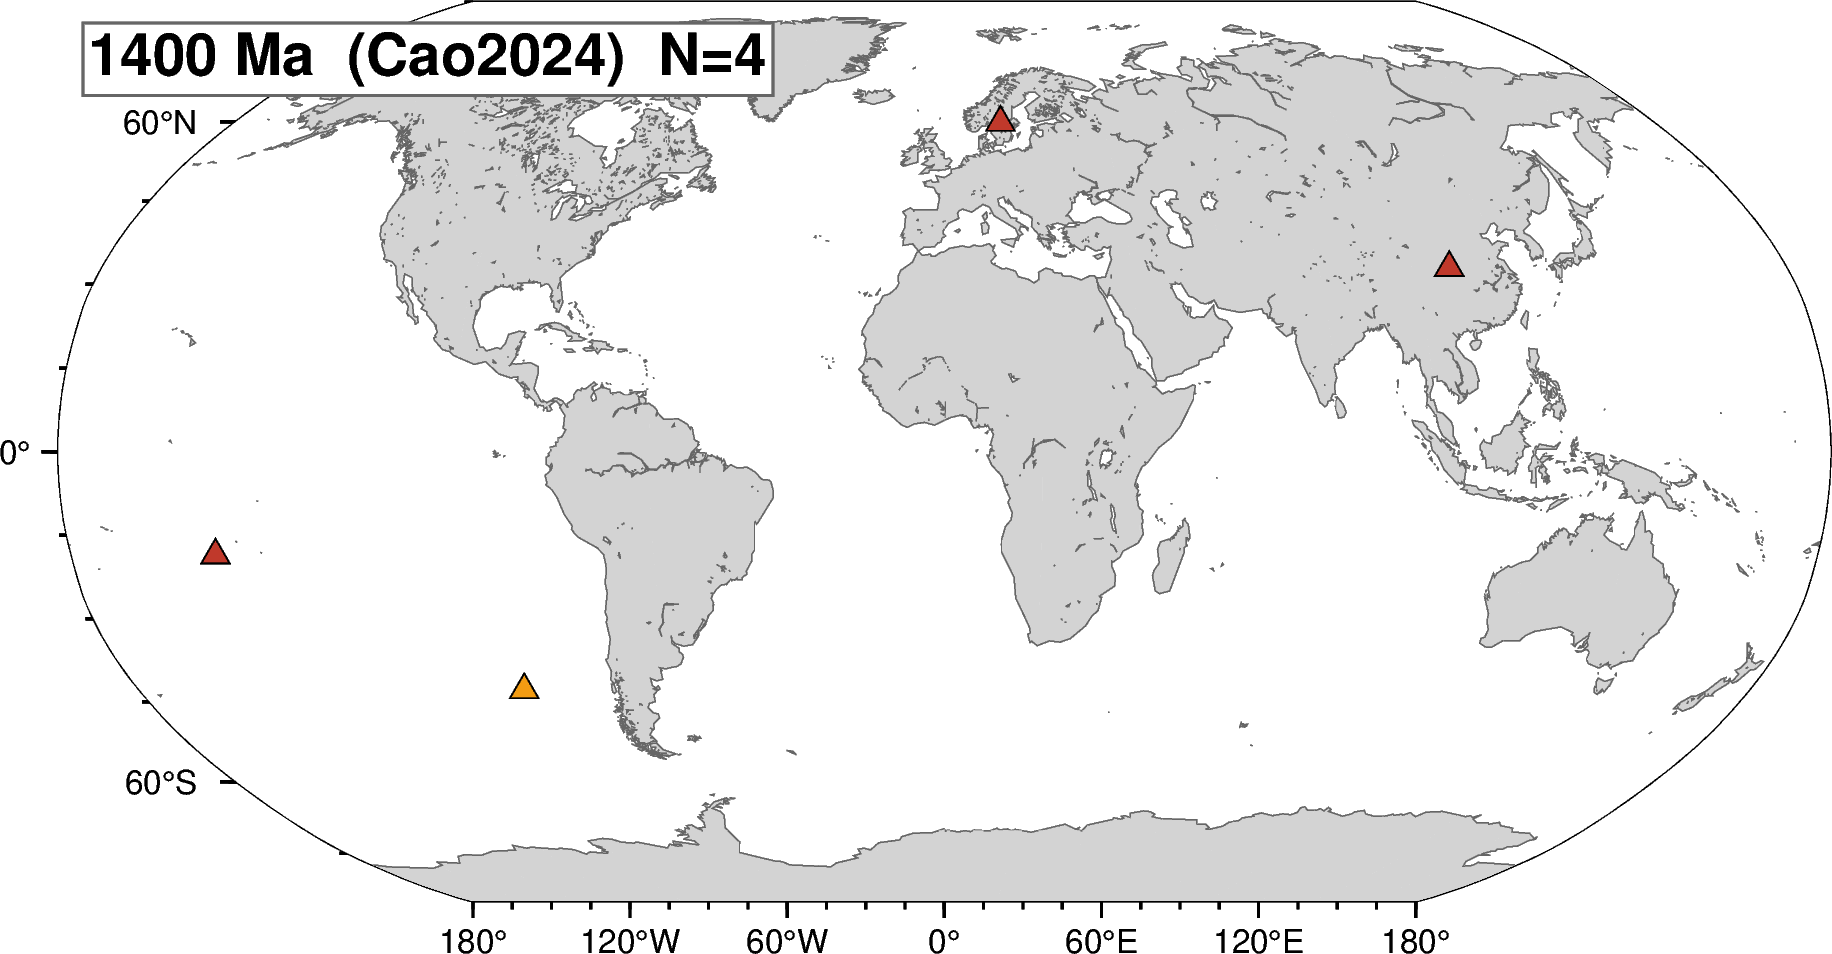

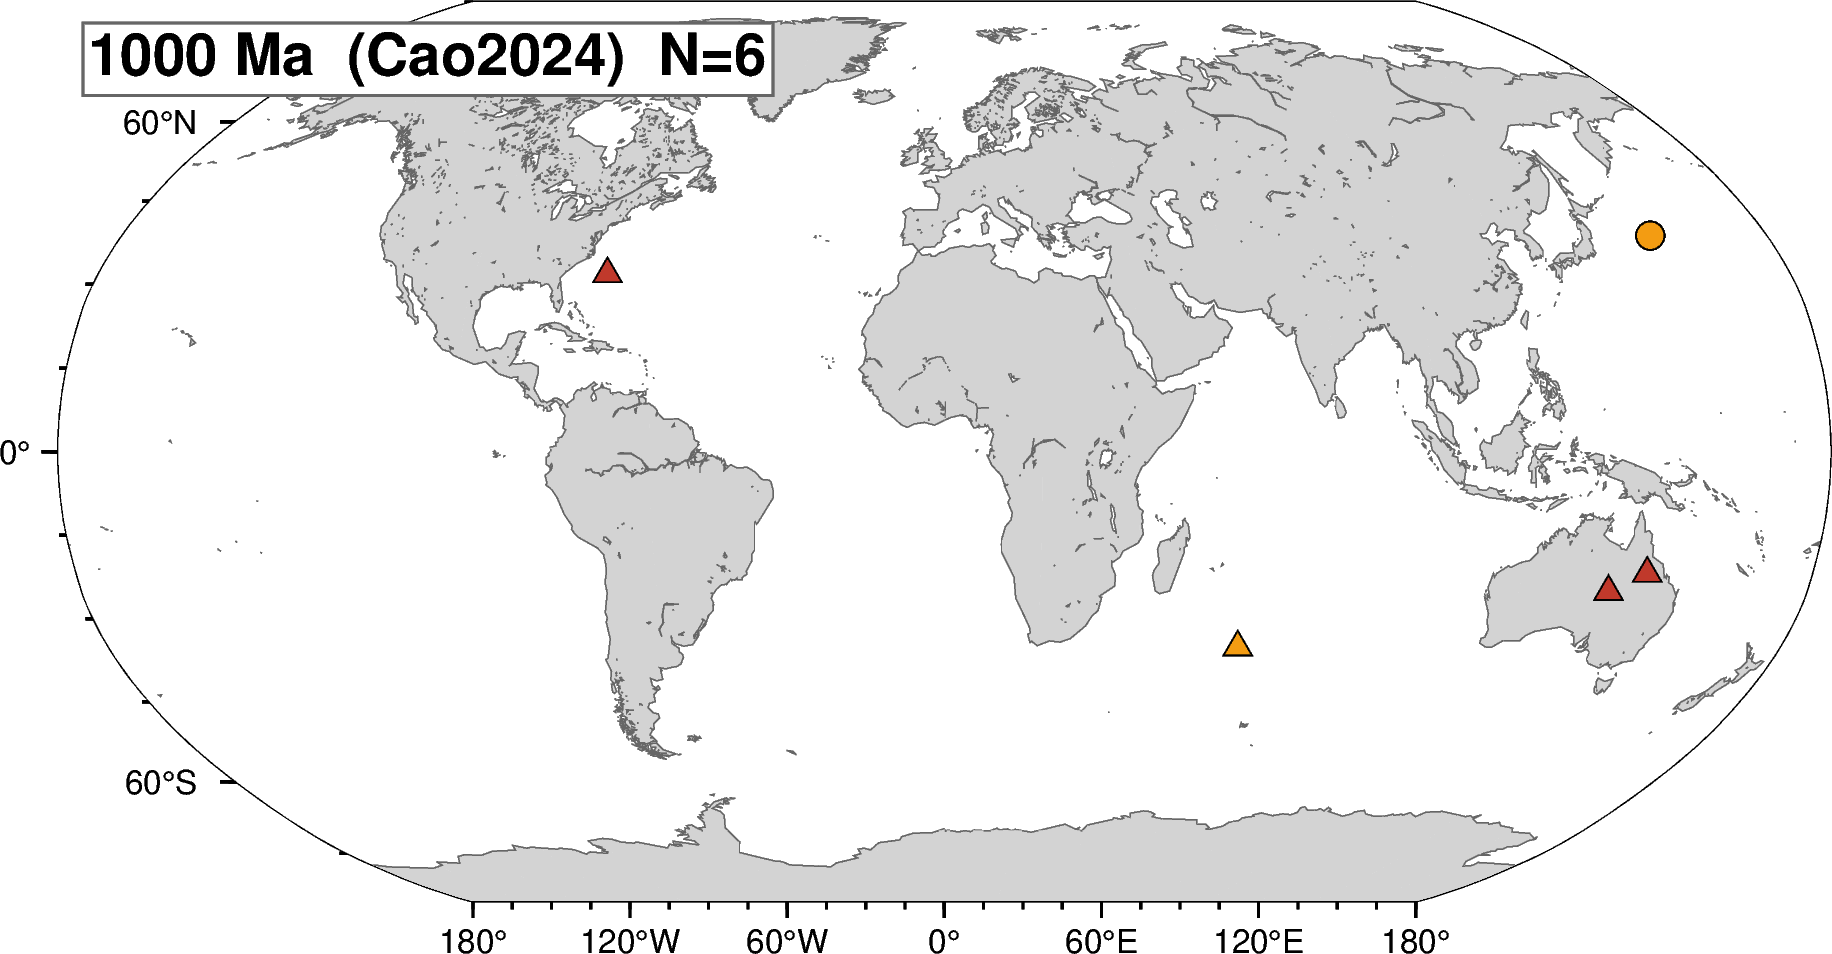

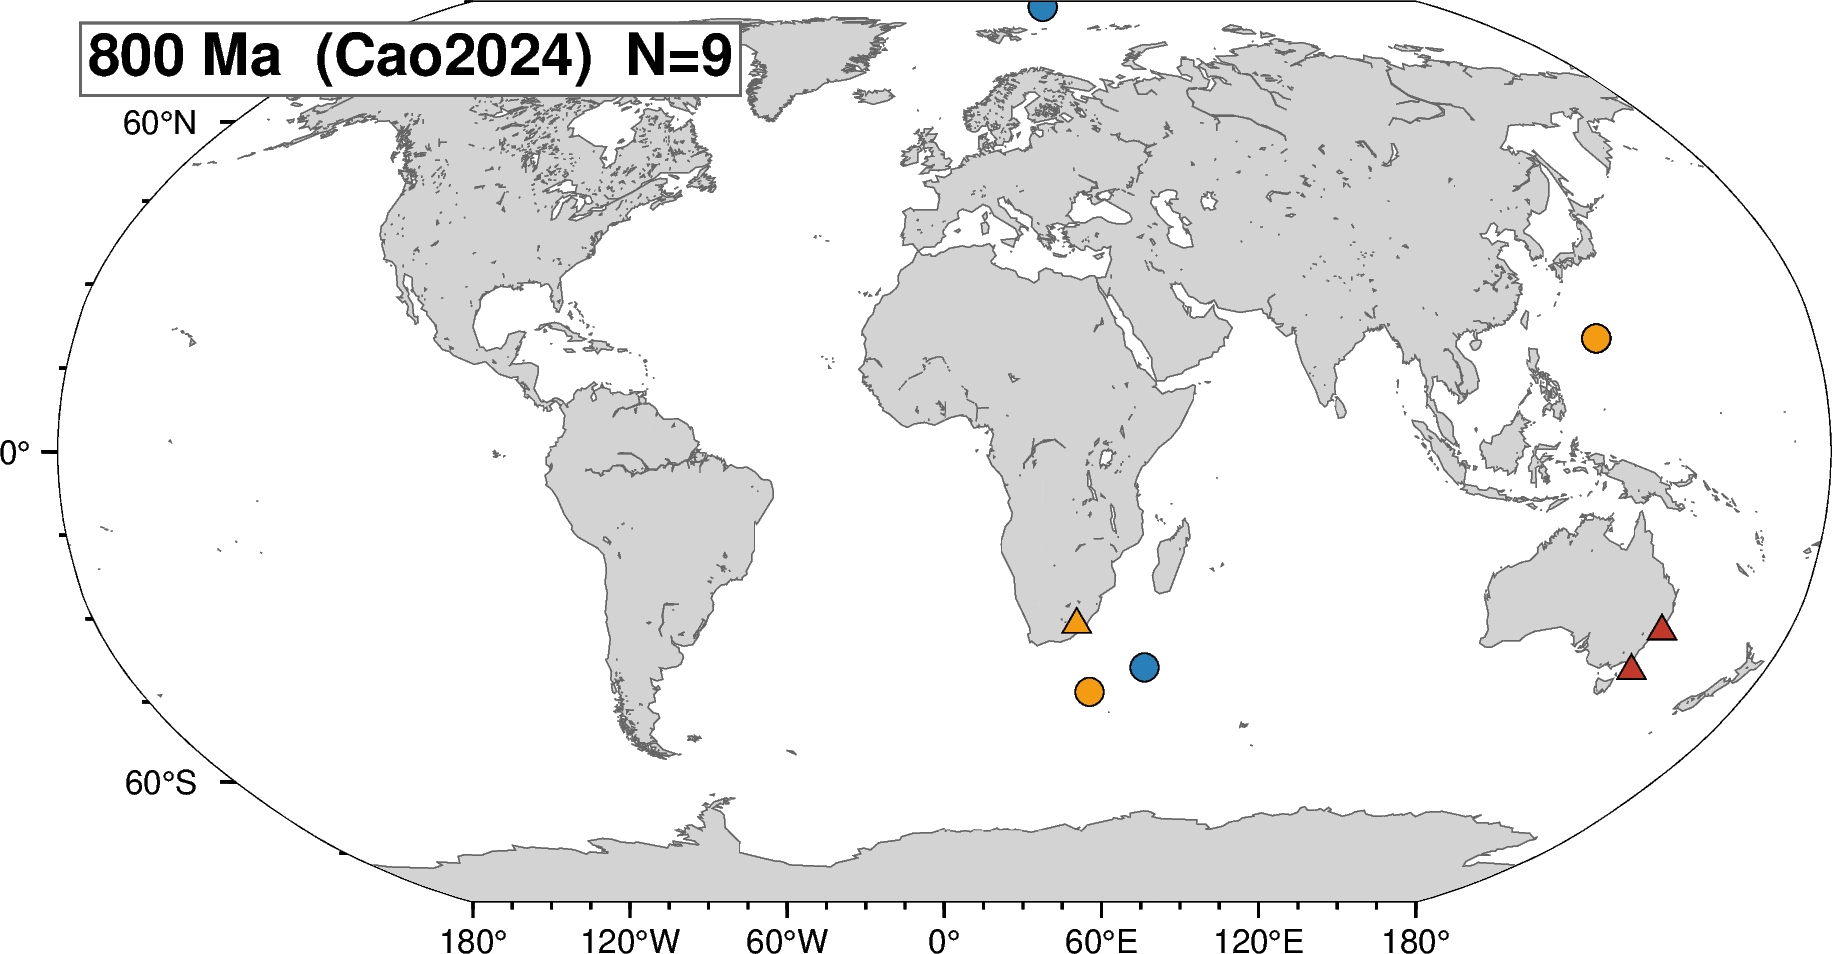

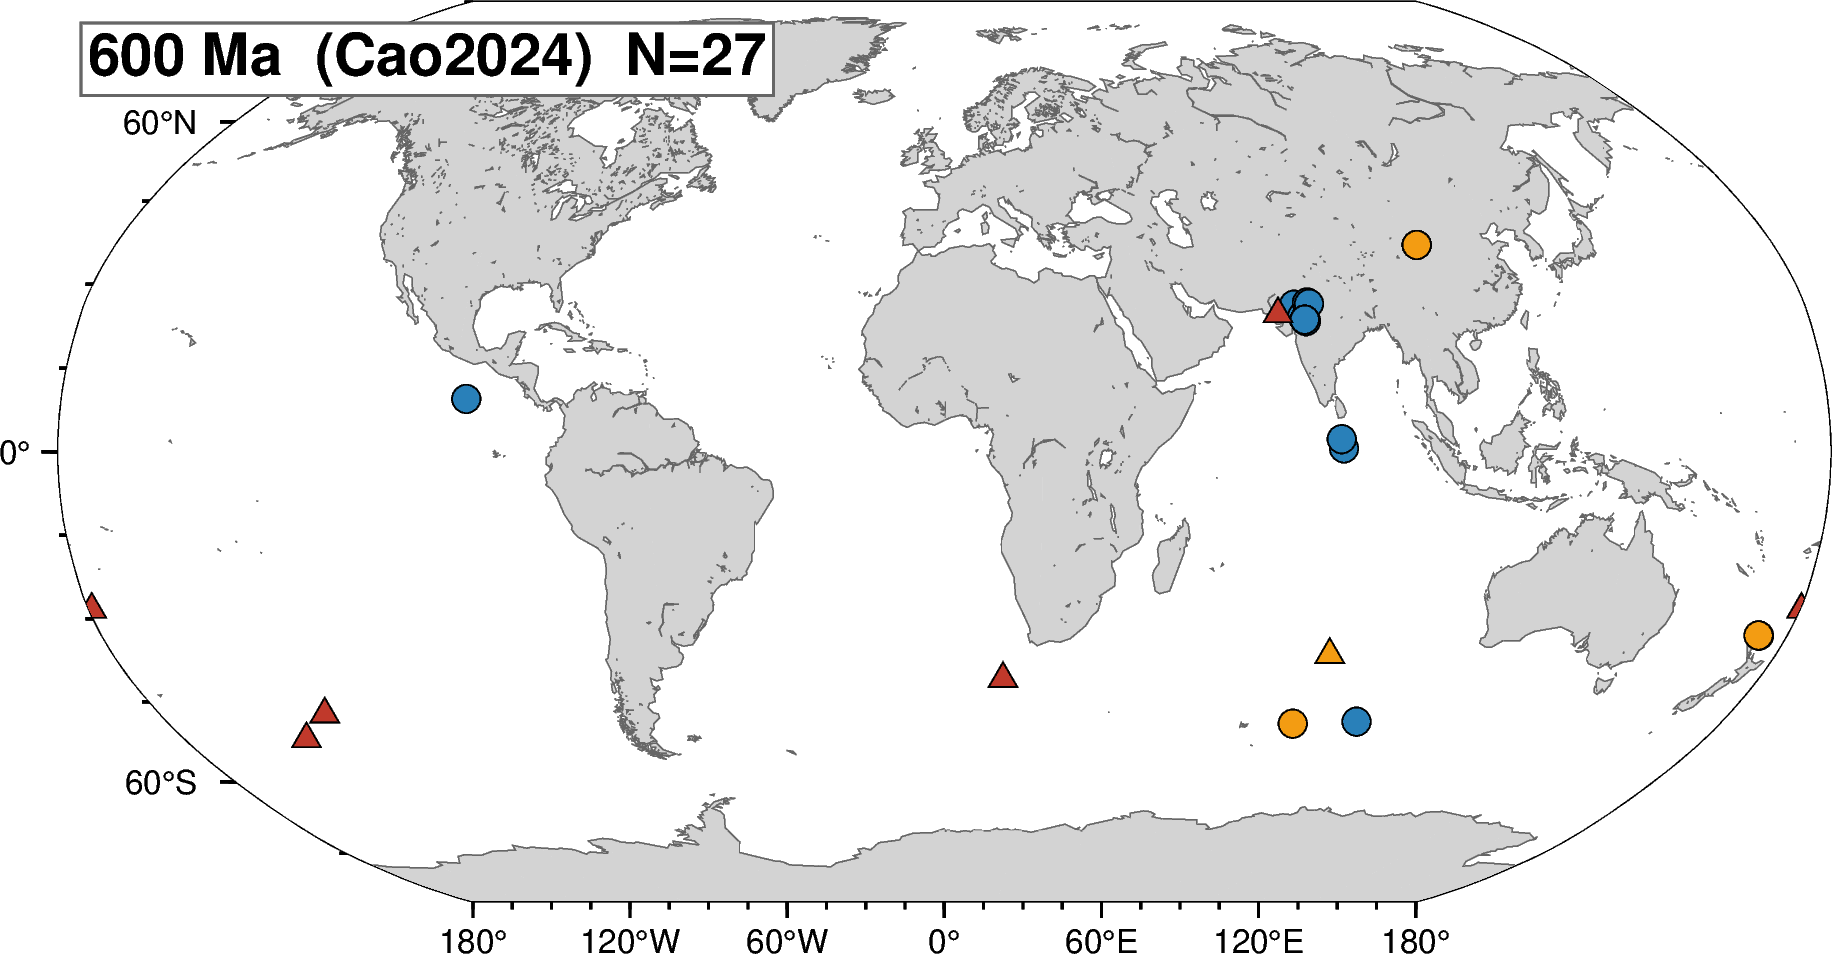

In [24]:
for age in SNAPSHOT_AGES_MA:
    snap = recon_df[recon_df["age_Ma"] >= age].copy()
    paleo_lons, paleo_lats = [], []
    for _, row in snap.iterrows():
        try:
            p = gplately.Points(
                plate_reconstruction=recon,
                lons=[row["longitude"]], lats=[row["latitude"]],
                time=0, plate_id=[int(row["plate_id"])],
                anchor_plate_id=ANCHOR_PLATE_ID,
            )
            rlons, rlats = p.reconstruct(time=float(age), return_array=True,
                                          anchor_plate_id=ANCHOR_PLATE_ID)
            paleo_lons.append(float(rlons[0])); paleo_lats.append(float(rlats[0]))
        except Exception:
            paleo_lons.append(np.nan); paleo_lats.append(np.nan)
    snap["snap_lon"], snap["snap_lat"] = paleo_lons, paleo_lats
    snap = snap.dropna(subset=["snap_lon", "snap_lat"])

    fig = pygmt.Figure()
    gplot.time = age
    fig.basemap(region=REGION, projection=PROJ, frame="af")
    fig.coast(region=REGION, projection=PROJ, water="white", shorelines=None)
    try:
        if gplot.continents is not None:
            gplot.plot_continents(fig, fill="gray95", pen="0.5p,gray45")
    except Exception:
        pass

    for (host, supergene), sty in STYLE.items():
        sub = snap[(snap["host_class"] == host) & (snap["supergene"] == supergene)]
        if len(sub) == 0: continue
        fig.plot(x=sub["snap_lon"], y=sub["snap_lat"],
                 style=sty["style"], fill=sty["fill"], pen="0.3p,black",
                 region=REGION, projection=PROJ)
    fig.text(text=f"{age:.0f} Ma  ({MODEL_NAME})  N={len(snap)}",
             position="TL", offset="0.25c/-0.25c", justify="TL",
             font="14p,Helvetica-Bold,black", fill="white", pen="0.6p,gray40")
    fig.show(width=900)


## 5. Deposition-rate time series through 1.8 Ga


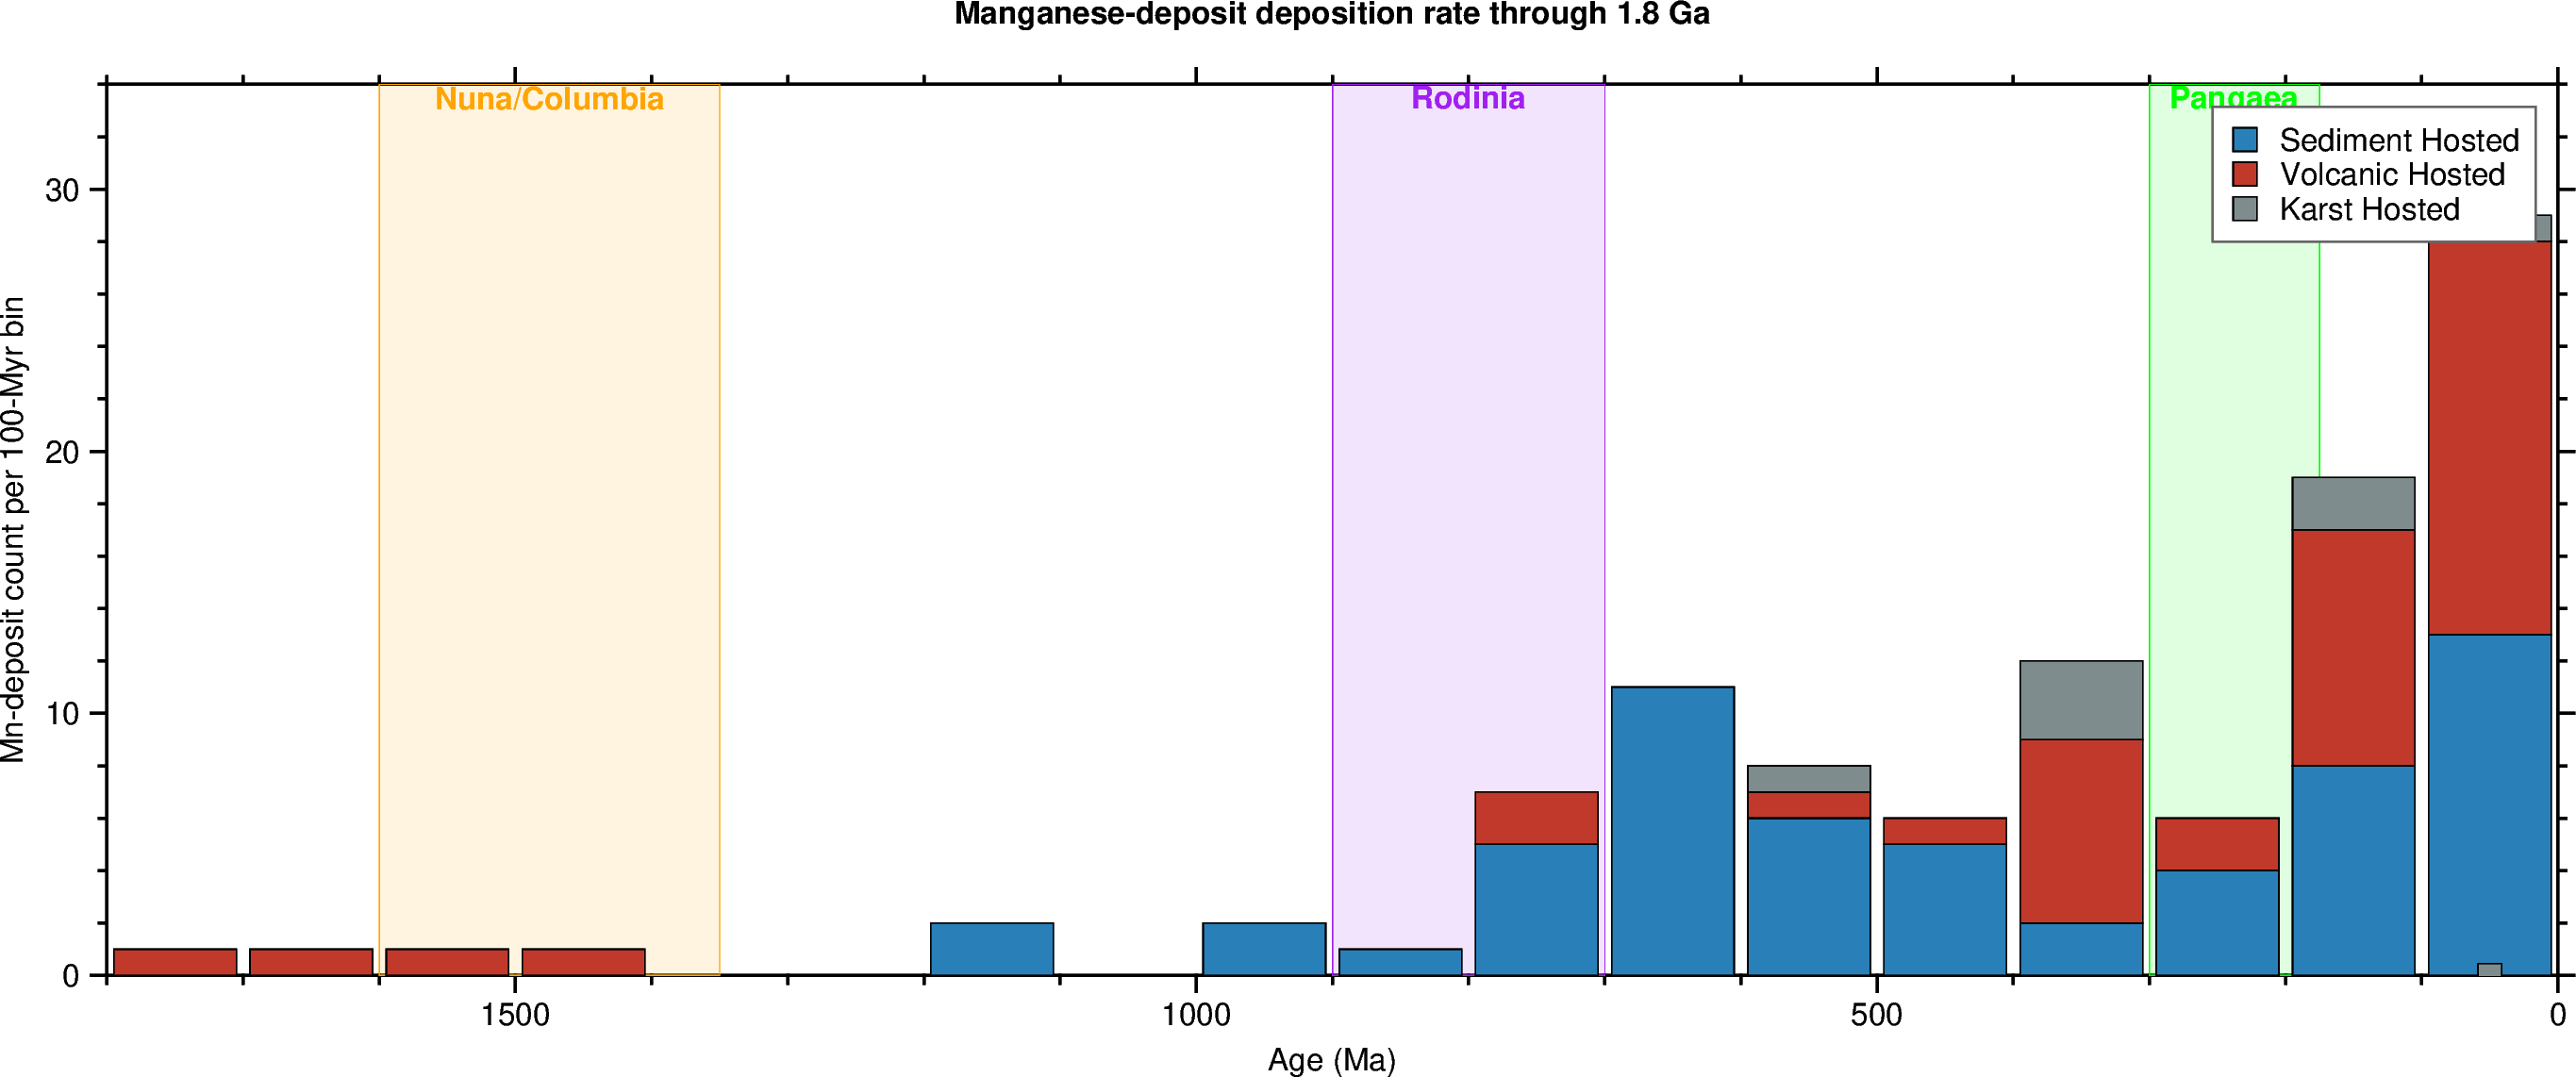

In [25]:
bins = np.arange(0, TIME_MAX_MA + TIME_BIN_MA, TIME_BIN_MA)
host_classes = ["sediment-hosted", "volcanic-hosted", "karst-hosted"]
colours      = ["#2980b9", "#c0392b", "#7f8c8d"]

# Pre-compute counts per bin per host class
counts_by_host = {}
for host in host_classes:
    c, _ = np.histogram(df[df["host_class"] == host]["age_Ma"], bins=bins)
    counts_by_host[host] = c

Y_MAX = int(sum(counts_by_host[h] for h in host_classes).max() * 1.15) + 1

fig = pygmt.Figure()
fig.basemap(region=[0, TIME_MAX_MA, 0, Y_MAX], projection="X-22c/8c",
            frame=["WSne+tManganese-deposit deposition rate through 1.8 Ga",
                   "xa500f100+lAge (Ma)",
                   f"yaf+lMn-deposit count per {TIME_BIN_MA}-Myr bin"])

# Supercontinent bands (as translucent rectangles)
for x0, x1, colour, label, xlabel in [
        (300, 175,  "green",   "Pangaea",         238),
        (900, 700,  "purple",  "Rodinia",         800),
        (1600, 1350, "orange", "Nuna/Columbia",  1475)]:
    fig.plot(x=[x0, x1, x1, x0, x0], y=[0, 0, Y_MAX, Y_MAX, 0],
             fill=f"{colour}@88", pen=f"0.2p,{colour}")
    fig.text(x=xlabel, y=Y_MAX - 0.5, text=label,
             font=f"8p,Helvetica-Bold,{colour}",
             justify="MC", no_clip=True)

# Stacked bars — draw each host class as vertical bars with cumulative bottom
prev_heights = np.zeros(len(bins) - 1)
bin_centres = bins[:-1] + TIME_BIN_MA / 2
for host, colour in zip(host_classes, colours):
    c = counts_by_host[host]
    # For each bin, plot a bar of height c[i] with base at prev_heights[i]
    # pyGMT "b" style: b<width>c/<base>c[u] plots a bar of width X ending at base
    for x, h_prev, delta in zip(bin_centres, prev_heights, c):
        if delta == 0: continue
        top = h_prev + delta
        # Draw rectangle as filled polygon
        fig.plot(x=[x - TIME_BIN_MA * 0.45, x + TIME_BIN_MA * 0.45,
                    x + TIME_BIN_MA * 0.45, x - TIME_BIN_MA * 0.45,
                    x - TIME_BIN_MA * 0.45],
                 y=[h_prev, h_prev, top, top, h_prev],
                 fill=colour, pen="0.3p,black")
    prev_heights += c
    # Use a phantom plot to make the legend entry
    fig.plot(x=[bin_centres[0]], y=[0], style="s0.3c", fill=colour,
             pen="0.3p,black", label=host.replace("-", " ").title())

fig.legend(position="JTR+jTR+o0.2c/0.2c", box="+gwhite+p0.5p,gray40")
fig.show(width=1100)


### How to read the deposition-rate time series

- **Neoproterozoic-Cambrian peak (~600-500 Ma)** — the Ediacaran-Cambrian deposition maximum. Basin-redox interpretation: rising atmospheric O₂ oxygenated shallow marine basins, precipitating Mn²⁺ as Mn⁴⁺ oxides.
- **Cryogenian minimum (~700-750 Ma)** — Sturtian and Marinoan Snowball Earth intervals limited habitable basin space and shut down Mn deposition.
- **Boring-Billion secondary peak (~1.4 Ga)** — sedimentary Mn concentrated in a small number of large deposits (Kalahari, XiangTan).
- **Phanerozoic tail (~300-0 Ma)** — steady state driven by supercontinent cycles and modern shelf-carbonate deposition (Nikopol, Chiatura, karst-hosted late-Cenozoic supergene).

The **Müller et al. (in review) key finding** is that supercontinent-assembly intervals (Nuna, Rodinia, Pangaea; shaded) do NOT strongly correlate with peak Mn deposition — the peaks correlate with basin-redox transitions, not climate.

**Note**: the bundled `deposit_counts_10Myr.csv` has the pre-computed counts used in the paper's Fig 3 — this notebook re-derives them for pedagogy.


## 6. Deep-time paleolatitudes (>1.8 Ga via GPMDB)

For 33 deposits older than Cao 2024's ~1.8 Ga coverage, the paper recovers paleolatitudes from nearby GPMDB Q≥3 paleomagnetic poles (within 15° and ±150 Myr of the deposit). This is what feeds the >1.8 Ga part of the paleolatitude-vs-age panel in the paper.


plot [WARNING]: Cannot use auto-legend -l for variable symbol color. Option -l ignored.
plot [WARNING]: Cannot use auto-legend -l for variable symbol color. Option -l ignored.
legend [WARNING]: File <stdin> is empty!


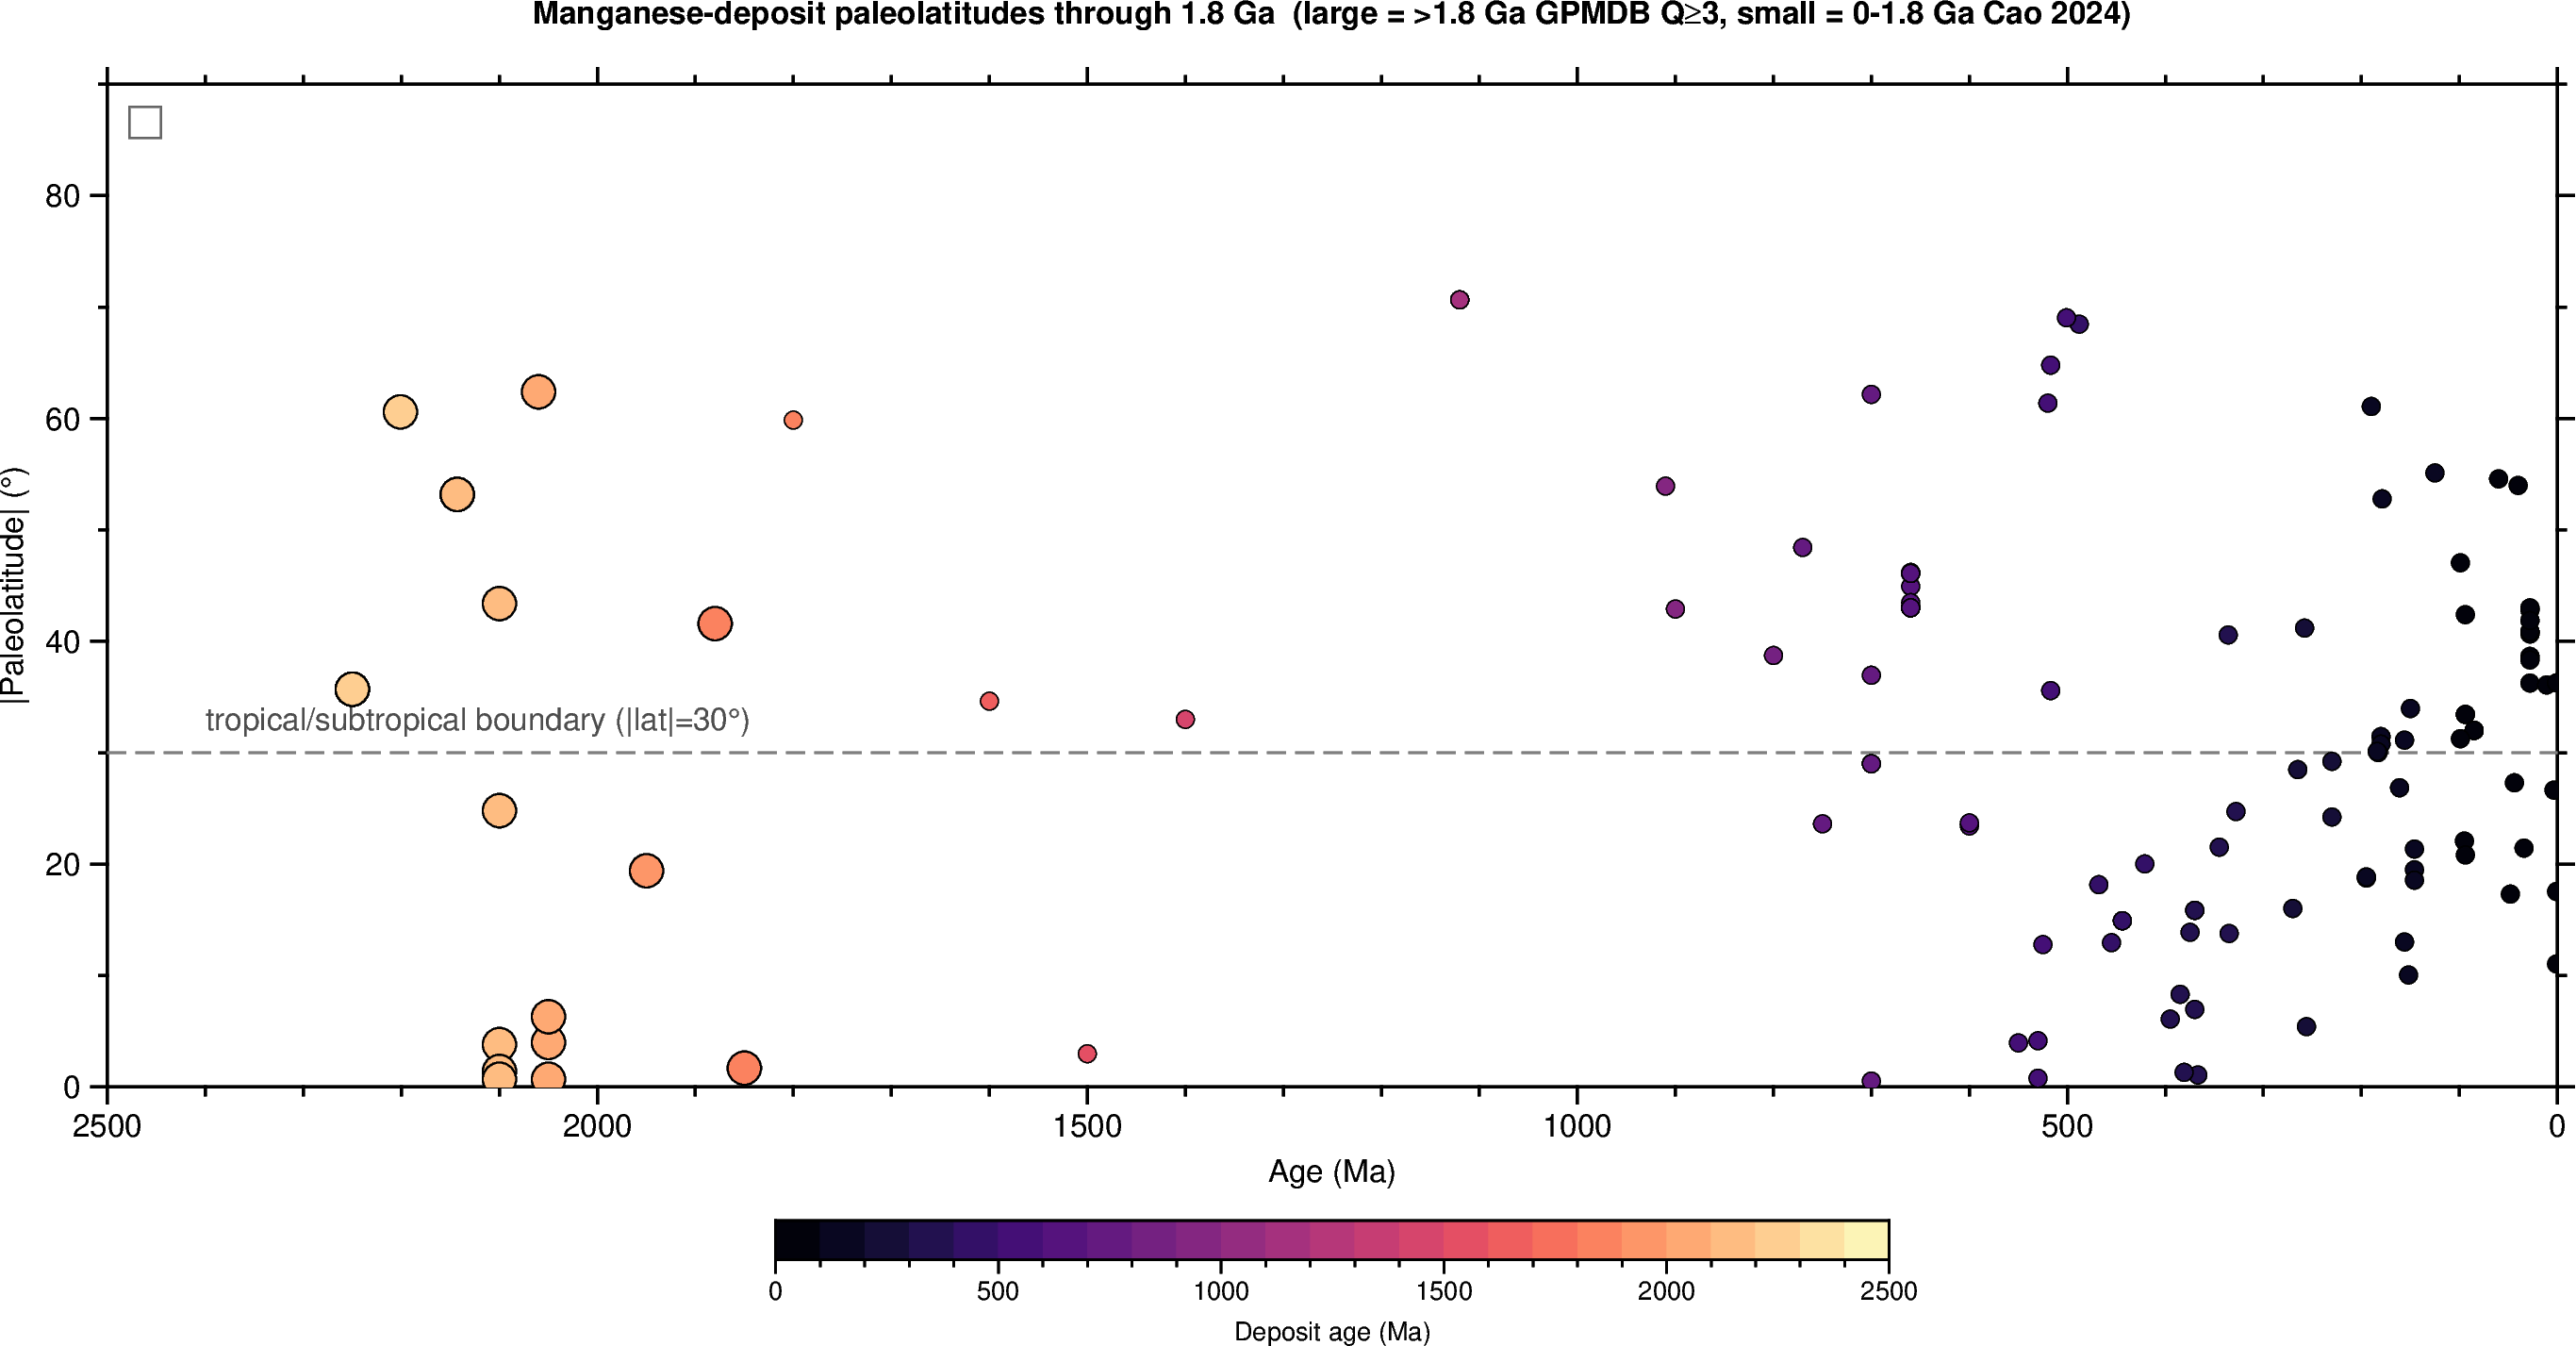

  Deep-time (>1.8 Ga) deposit paleolatitude range: 0.7 - 84.0°
  Mean |paleolat| of >1.8 Ga deposits: 34.7°
  Mean |paleolat| of Cao 2024 (<1.8 Ga) deposits: 31.4°


In [26]:
deep_df["abs_paleolat"] = deep_df["abs_paleolat_Q3"].abs() \
    if "abs_paleolat_Q3" in deep_df.columns else np.nan
recon_deep = recon_df.dropna(subset=["abspaleolat"]).copy()

fig = pygmt.Figure()
fig.basemap(region=[0, 2500, 0, 90], projection="X-22c/9c",
            frame=["WSne+tManganese-deposit paleolatitudes through 1.8 Ga  "
                   "(large = >1.8 Ga GPMDB Q≥3, small = 0-1.8 Ga Cao 2024)",
                   "xa500f100+lAge (Ma)",
                   "yaf+l|Paleolatitude| (°)"])

# Tropical/subtropical reference
fig.plot(x=[2500, 0], y=[30, 30], pen="0.6p,gray50,-")
fig.text(x=2400, y=32, text="tropical/subtropical boundary (|lat|=30°)",
         font="8p,Helvetica,gray30", justify="LB", no_clip=True)

# Deep-time (>1.8 Ga) GPMDB — larger circles, coloured by age
pygmt.makecpt(cmap="magma", series=[0, 2500, 100], background="o")
if len(deep_df) > 0:
    fig.plot(x=deep_df["age_Ma"], y=deep_df["abs_paleolat_Q3"],
             style="c0.30c", fill=deep_df["age_Ma"], cmap=True, pen="0.4p,black",
             label="Deep-time GPMDB Q≥3 (>1.8 Ga)")

# Cao 2024 (0-1.8 Ga) — smaller circles
if len(recon_deep) > 0:
    fig.plot(x=recon_deep["age_Ma"], y=recon_deep["abspaleolat"],
             style="c0.16c", fill=recon_deep["age_Ma"], cmap=True, pen="0.25p,black",
             label="Cao 2024 (0-1.8 Ga)")

fig.colorbar(position="JBC+w10c/0.35c+h+o0/1.2c", frame=["a500f100", "x+lDeposit age (Ma)"])
fig.legend(position="JTL+jTL+o0.2c/0.2c", box="+gwhite+p0.5p,gray40")
fig.show(width=1100)

# Summary
print(f"  Deep-time (>1.8 Ga) deposit paleolatitude range: "
      f"{deep_df['abs_paleolat_Q3'].min():.1f} - {deep_df['abs_paleolat_Q3'].max():.1f}°")
print(f"  Mean |paleolat| of >1.8 Ga deposits: {deep_df['abs_paleolat_Q3'].mean():.1f}°")
print(f"  Mean |paleolat| of Cao 2024 (<1.8 Ga) deposits: {recon_deep['abspaleolat'].mean():.1f}°")


### How to read the paleolatitude plot

The Müller et al. finding is that Mn-deposit paleolatitudes are **not tightly clustered near the equator** as they would be if climate controlled deposition (e.g. via warm carbonate factory geometry). Instead the paleolatitudes span all latitudes broadly, consistent with **basin redox** (not climate) as the primary control. The null-test panels in the full paper show that the observed paleolatitude distribution matches the "continental availability" null — i.e. deposits are found wherever continent existed at their age, not preferentially at low latitudes.


## Extend this — full analysis pipeline

This notebook is the visualisation layer. To reproduce the full paper's analysis (declustered occurrences, null tests, arc-availability test, Fig 4 controls panel):

```bash
git clone https://github.com/EarthByte/Manganese-paleogeography.git
cd Manganese-paleogeography
conda env create -f environment.yml && conda activate gplately-pygmt
./make_all_figures.sh
```

The full pipeline uses:

- **4264-occurrence declustering** (Fig 3d in the paper) — reduces the raw MED/RRUFF occurrence catalog to 265 declustered 1° × 100-Myr cells.
- **Continental-availability null test** — random points on paleo-continents at each deposit's age; the observed paleolatitude distribution is compared to this null (Fig 3b).
- **Continental-arc null test** — trench segments within 300 km of a reconstructed continent, weighted by trench length. Volcanic-hosted deposits should follow this null if they're arc-related (Fig S1).

## Related notebooks

- **T09-T11** — Wu 2023 zircon compilation, another Cao-2024-based deposit workflow.
- **T55-T60** — mineral-exploration cluster (SW-Pacific porphyry, sediment-hosted Cu, deep-time porphyry).
- **T29-T37** — paleomagnetism cluster; the >1.8 Ga paleolatitude story is a real-world use case for the same GPMDB workflow.

## Sources

- **Müller, R.D., Bermanec, M., Li, Y., Boulila, S., Dutkiewicz, A. & Hazen, R.M. (in review, *Geology*).** Basin redox, not climate, controlled manganese deposition over 1.8 billion years.
- Full workflow + all derived CSVs: <https://github.com/EarthByte/Manganese-paleogeography>
- **Maynard, J.B. (2010).** The chemistry of manganese ores through time. *Economic Geology* 105, 535-552. doi:10.2113/gsecongeo.105.3.535.
- **Cao, X., Collins, A.S., Pisarevsky, S.A., Flament, N., Li, S., Hasterok, D. & Müller, R.D. (2024).** Earth's tectonic and plate boundary evolution over 1.8 billion years. *Geoscience Frontiers* 15, 101922. doi:10.1016/j.gsf.2024.101922.
- **Pisarevsky, S.A. et al. (2022).** An updated internet-based Global Paleomagnetic Database. *Earth-Science Reviews* 235, 104258.
- **Schulz, K.J. et al. (2017).** Critical mineral resources of the United States. *USGS Professional Paper 1802*.
